In [1]:
# Importing all the required packages
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data as Data
import torchvision
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import sklearn
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)
import warnings
warnings.filterwarnings("ignore")
torch.manual_seed(1)

In [2]:
# Hyper parameters
# For the number of epochs
EPOCH = 1
# For batch size
BATCH_SIZE = 64
# Learning rate
LR = 0.001

DOWNLOAD_MNIST = True
# Downloading the mnist data
train_data = torchvision.datasets.MNIST(
    root = "./mnist/",
    train = True,
    transform = torchvision.transforms.ToTensor(), # FloatTensor of the shape (color X heigh X width)
    download = DOWNLOAD_MNIST
)

Size of the data: torch.Size([60000, 28, 28])
Size of the label: torch.Size([60000, 28, 28])


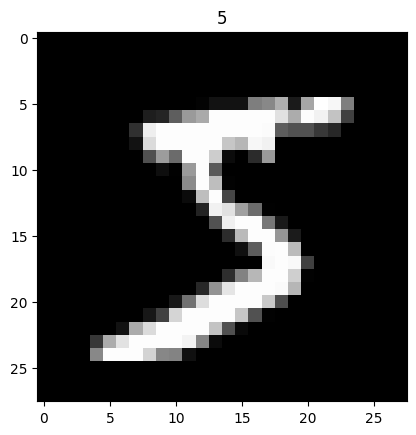

In [3]:
# Plotting the size of the data and variables
data_size = train_data.data.size()
print(f"Size of the data: {data_size}")

label_size = train_data.targets.size()
print(f"Size of the label: {data_size}")

# Plotting the first image in the data
plt.imshow(train_data.data[0].numpy(), cmap = "gray")
plt.title("%i" %train_data.targets[0])
plt.show()

In [4]:
# For easy mini-batch return in training
train_loader = Data.DataLoader(dataset = train_data, batch_size = BATCH_SIZE, shuffle = True)

In [5]:

test_data = torchvision.datasets.MNIST(root = "./mnist/", train = False)
test_x = Variable(torch.unsqueeze(test_data.data, dim = 1)).type(torch.FloatTensor)[:2000]/255.
test_y = test_data.targets[:2000]

In [6]:
# Define a Convolutional Neural Network (CNN) class
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()  # Initialize the parent class (nn.Module)

        # Define the first convolutional layer with a sequential block
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,        # Number of input channels (e.g., grayscale image has 1 channel)
                out_channels=16,      # Number of output channels (number of filters)
                kernel_size=5,        # Size of each filter (5x5)
                stride=1,             # Stride of the convolution
                padding=2             # Padding to maintain the spatial dimensions
            ),
            nn.ReLU(),               # Activation function
            nn.MaxPool2d(kernel_size=2)  # Max pooling layer with a 2x2 window
        )

        # Define the second convolutional layer with a sequential block
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,       # Number of input channels from the previous layer
                out_channels=32,      # Number of output channels (number of filters)
                kernel_size=5,        # Size of each filter (5x5)
                stride=1,             # Stride of the convolution
                padding=2             # Padding to maintain the spatial dimensions
            ),
            nn.ReLU(),               # Activation function
            nn.MaxPool2d(kernel_size=2)  # Max pooling layer with a 2x2 window
        )

        # Define a fully connected layer (linear layer) for the output
        self.out = nn.Linear(
            in_features=32 * 7 * 7,  # Number of input features (flattened from conv2 output)
            out_features=10          # Number of output features (number of classes)
        )

    # Define the forward pass
    def forward(self, inputs):
        x = self.conv1(inputs)         # Pass inputs through the first conv layer
        x = self.conv2(x)              # Pass the result through the second conv layer
        x = x.view(x.size(0), -1)      # Flatten the output from conv2 for the fully connected layer
        output = self.out(x)           # Pass the flattened output through the fully connected layer
        return output, x               # Return the final output and the flattened features from the last conv layer

In [7]:
cnn = CNN()
print(cnn)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


In [8]:
optimizer = torch.optim.Adam(cnn.parameters(), lr = LR)
loss_func = nn.CrossEntropyLoss()

In [9]:
try: 
    from sklearn.manifold import TSNE
    HAS_SK = True
except: 
    HAS_SK = False
    print("Please install sklearn for layer visualisation, if not there.")

In [10]:
# Function to plot 2D embeddings with labels
def plot_with_labels(lowDWeights, labels):
    plt.cla()  # Clear the current axes
    X, Y = lowDWeights[:, 0], lowDWeights[:, 1]  # Extract x and y coordinates
    for x, y, s in zip(X, Y, labels):  # Iterate over coordinates and labels
        # Map label to a color and plot text with that background color
        c = cm.rainbow(int(255 * s / 9))
        plt.text(x, y, s, backgroundcolor=c, fontsize=9)
    # Set plot limits and title
    plt.xlim(X.min(), X.max())
    plt.ylim(Y.min(), Y.max())
    plt.title("Visualise last layer")
    plt.show()  # Display the plot

Epoch:  0 | train loss: 2.2995 | test accuracy: 0.14


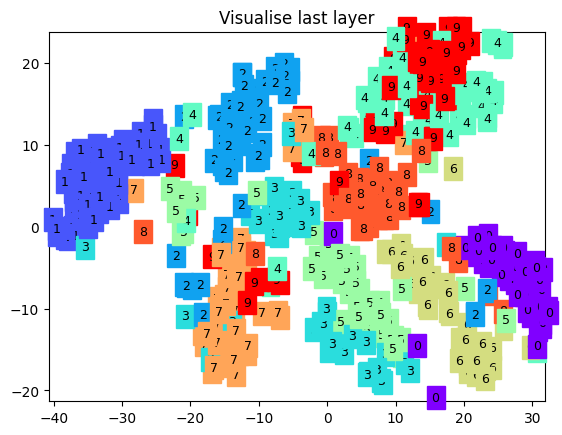

Epoch:  0 | train loss: 0.3153 | test accuracy: 0.89


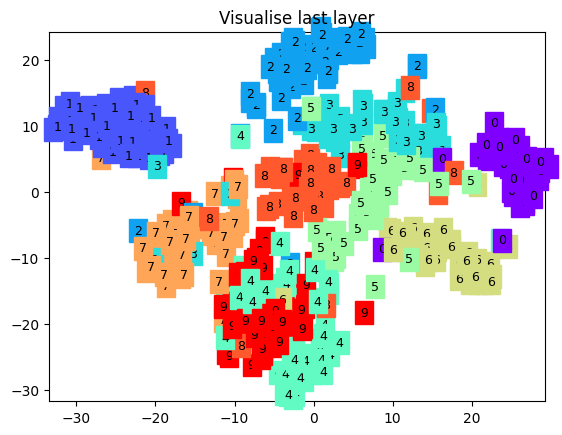

Epoch:  0 | train loss: 0.2056 | test accuracy: 0.93


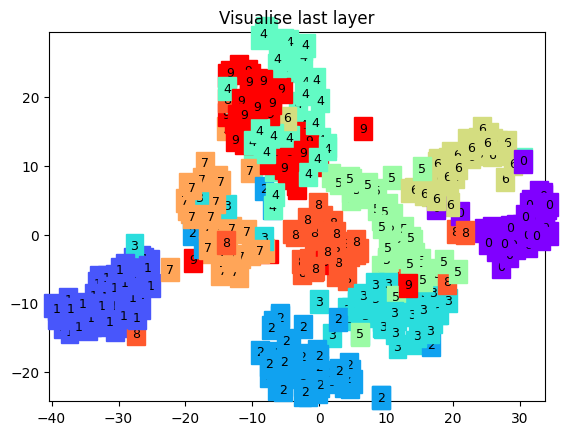

Epoch:  0 | train loss: 0.2297 | test accuracy: 0.96


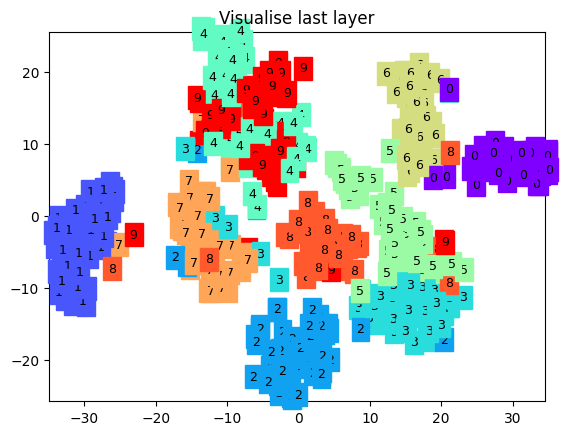

Epoch:  0 | train loss: 0.2402 | test accuracy: 0.96


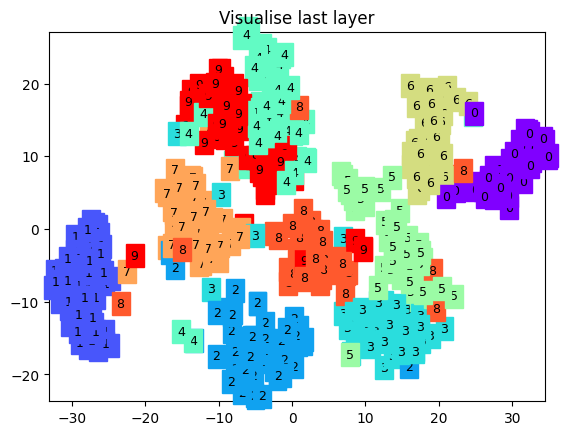

Epoch:  0 | train loss: 0.1019 | test accuracy: 0.96


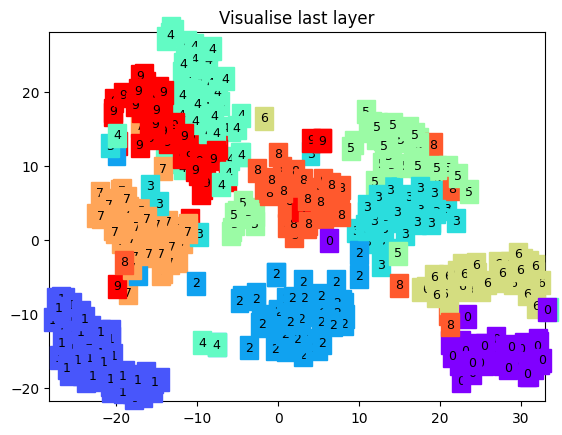

Epoch:  0 | train loss: 0.1068 | test accuracy: 0.96


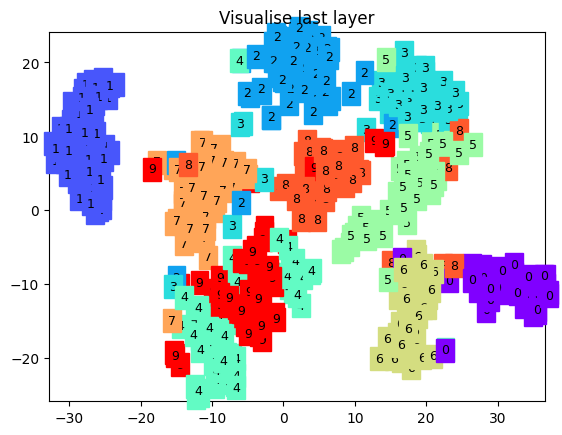

Epoch:  0 | train loss: 0.0388 | test accuracy: 0.97


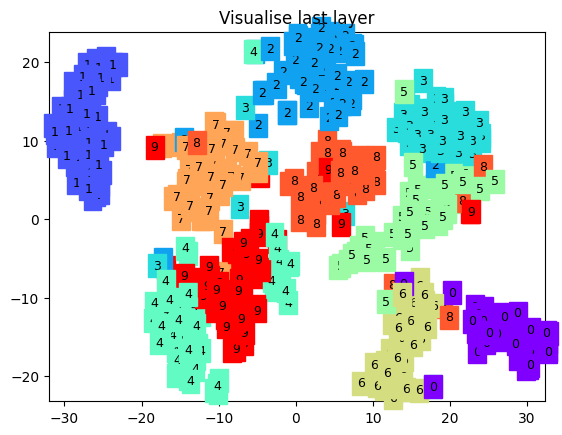

Epoch:  0 | train loss: 0.0109 | test accuracy: 0.97


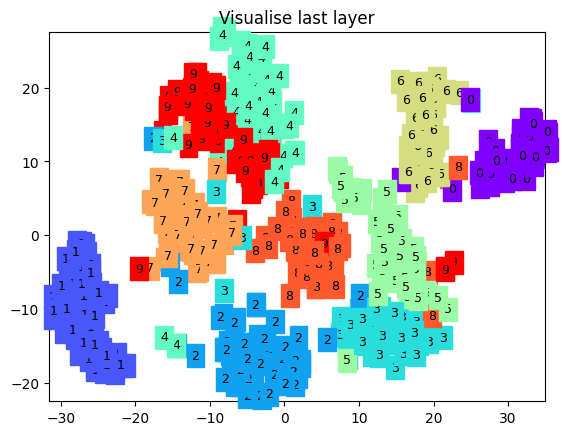

Epoch:  0 | train loss: 0.0692 | test accuracy: 0.97


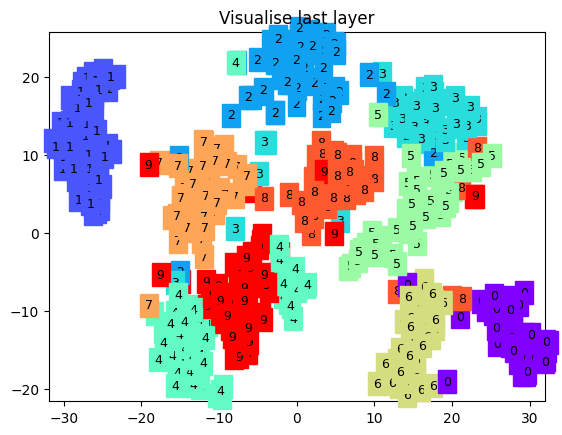

In [11]:
plt.ion()  # Turn on interactive mode for dynamic plotting

# Main training loop
for epoch in range(EPOCH):
    for step, (x, y) in enumerate(train_loader):
        b_x = Variable(x)  # Wrap input data in Variable
        b_y = Variable(y)  # Wrap target labels in Variable

        output = cnn(b_x)[0]  # Forward pass through the network
        loss = loss_func(output, b_y)  # Compute loss

        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Backpropagate to compute gradients
        optimizer.step()  # Update network parameters

        if step % 100 == 0:  # Every 100 steps, evaluate and visualize
            test_output, last_layer = cnn(test_x)  # Forward pass on test data
            pred_y = torch.max(test_output, 1)[1].data.squeeze()  # Get predicted labels
            accuracy = (pred_y == test_y).sum().item() / float(test_y.size(0))  # Calculate accuracy
            print("Epoch: ", epoch, "| train loss: %.4f" % loss.data, "| test accuracy: %.2f" % accuracy)  # Print metrics
            
            if HAS_SK:  # If sklearn (TSNE) is available
                tsne = TSNE(perplexity=30, n_components=2, init="pca", n_iter=5000)  # Initialize TSNE
                plot_only = 500  # Number of points to plot
                low_dim_embs = tsne.fit_transform(last_layer.data.numpy()[:plot_only, :])  # Compute 2D embeddings
                labels = test_y.numpy()[:plot_only]  # Get corresponding labels
                plot_with_labels(lowDWeights=low_dim_embs, labels=labels)  # Plot embeddings